<a href="https://www.kaggle.com/code/ramchundi/credit-fraud-log-reg?scriptVersionId=309814907" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.datasets import make_classification
from cuml.linear_model import LogisticRegression
#model = LogisticRegression()
import cudf
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score,precision_recall_curve,auc

In [2]:
def load_data(path):
  df = pd.read_csv(path)
  return df

def visualise(df):
  sns.countplot(x="Class", data=df)
  print(df.shape)
  print("\n")
  print(df.isnull().sum())
  plt.style.use('seaborn-v0_8')
  df.hist(bins=50,figsize=(20,14))
  plt.show()


def trainsplit(df):
  #df = df.drop('Time',axis = 1)
  x=df.drop('Class',axis=1)
  y=df['Class']
  x_train,x_test,y_train,y_test = train_test_split(
x,y, test_size=0.30, random_state=42)
  y_train.value_counts()
  return x_train,x_test,y_train,y_test


def undersample(x_train,y_train):
    train_df = pd.concat([x_train, y_train], axis=1)

    fraud = train_df[train_df.Class == 1]
    normal = train_df[train_df.Class == 0]

    normal_sample = normal.sample(len(fraud), random_state=42)

    df_under = pd.concat([fraud, normal_sample])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]

    return X_under, y_under


def evaluate(x_test,y_test,model,threshold):

 
  y_prob = model.predict_proba(x_test).values[:,1]
  y_pred = (y_prob >= threshold).astype(int)                                  #filtering the y_pred with a particular probbbb
  score = accuracy_score(y_test,y_pred)
  print(score)
  cm = confusion_matrix(y_test,y_pred)
  print(cm)
  cp = classification_report(y_test,y_pred)
  print(cp)
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix at threshold "+ str(threshold))
  plt.show()
  #print(classification_report(y_test,y_pred))
  return y_pred



def grid_with_SMOTE(x_train,y_train):
     from imblearn.pipeline import Pipeline
     from imblearn.over_sampling import SMOTE
     model = LogisticRegression(max_iter = 2000)
    #   PREVENTION OF DATA LEAKAGE IN CROSS VALIDATION 
    #using smote in pipeline to avoid data leakage into the cross train-validation which leads to incorrect score(overfit(not exactly)) 
    #The CV Split: When CV splits say 400 points into 5 folds, a synthetic point in Fold 1 likely has a "parent" or "neighbor" in Fold 2.
    #The Leak: When the model trains on Folds 2–5 and validates on Fold 1, it is effectively seeing data it already "knows" from the SMOTE step.
     pipeline = Pipeline([
    ('smote', SMOTE()),
    ('model', model)
                         ])

     param_grid = {
        'model__C': [0.1, 0.01, 1],   # regularization
        'model__class_weight': (
            [{0:1, 1:y} for y in [100, 300, 587]]
        )
                  }
    # grid = GridSearchCV(estimator=pipeline,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,  
        cv=StratifiedKFold(shuffle=True,random_state = 42),
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
                        )
     grid.fit(x_train,y_train)
     print("best params " + str(grid.best_params_))
     print("the best score AUC"+str(grid.best_score_))
     model = grid.best_estimator_
     return model

def grid_with_downsampling(x_train,y_train):
     model = LogisticRegression(max_iter = 2000)
     x_under,y_under = undersample(x_train,y_train)
     #visualise(resampled)
     param_grid =  {
        'C': [0.1, 0.01, 1],   # regularization
        'class_weight': (
            [{0:1, 1:y} for y in [100, 300, 587]]
        )
                  }
  
     #grid = GridSearchCV(estimator=model,param_grid=param_grid,cv=StratifiedKFold(shuffle=True),scoring= 'recall',verbose=1,n_jobs=-1) 
     grid = RandomizedSearchCV(
     model,
     param_distributions=param_grid,
     n_iter=10,   # only try 10 combos
     cv=StratifiedKFold(shuffle=True,random_state = 42),
     scoring='average_precision',
     n_jobs=-1,
     verbose=1
            )
     grid.fit(x_under,y_under)
     print("best params " + str(grid.best_params_))
     print("the best score AUC"+str(grid.best_score_))
     model = grid.best_estimator_
     return model
    
    
    
def oversample(x_train,y_train):
    oversample = SMOTE()
    #f = train_sample.drop(['Time','Class'],axis = 1)     #OMG i am forget that i already removed the time in the train_test_split 
    #target = df['Class'] 
    x_resampled,y_resampled = oversample.fit_resample(x_train,y_train)
    print(x_resampled.shape)
    print(y_resampled.shape)
    resampled = pd.concat([x_resampled, y_resampled], axis=1)                 # dont need this!! just made to visualise this!!!!!!!!
    sns.countplot(x="Class", data=resampled)
    return x_resampled,y_resampled,resampled


def AUC_PR(model,x_train,y_train):                                             #provides an assurance of 95% recall 
     
    y_score = cross_val_predict( ###please refer the documentation for clarity
        model,
        x_train,
        y_train,
        cv=StratifiedKFold(shuffle=True,random_state=42),
        method='predict_proba',
        n_jobs=-1
    )[:,1]

    
   # get precsion and recall and show PR curve on the train
    
    precision,recall,thresholds = precision_recall_curve(y_train,y_score)
    #model_FPR, model_TPR,thresholds = roc_curve(y_test,y_score) //  hopeless here 
    plt.plot(recall,precision)
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.title("Precsion-recalll curve(PR) ====train")
    plt.legend()
    plt.show()

    
    # get the thresholds with min_recall as 93%
    min_recall = 0.93
    best_thresh = 0
    best_precision = 0

    for i in range(len(thresholds)):
        if recall[i+1] >= min_recall:
            if precision[i+1] > best_precision:
                best_precision = precision[i+1]
                best_thresh = thresholds[i]

    return best_thresh

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

(284807, 31)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


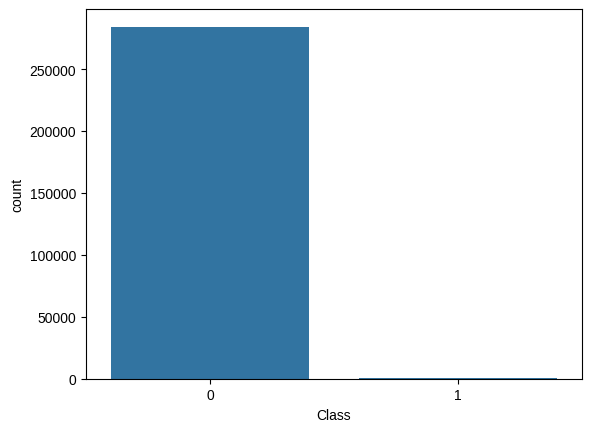

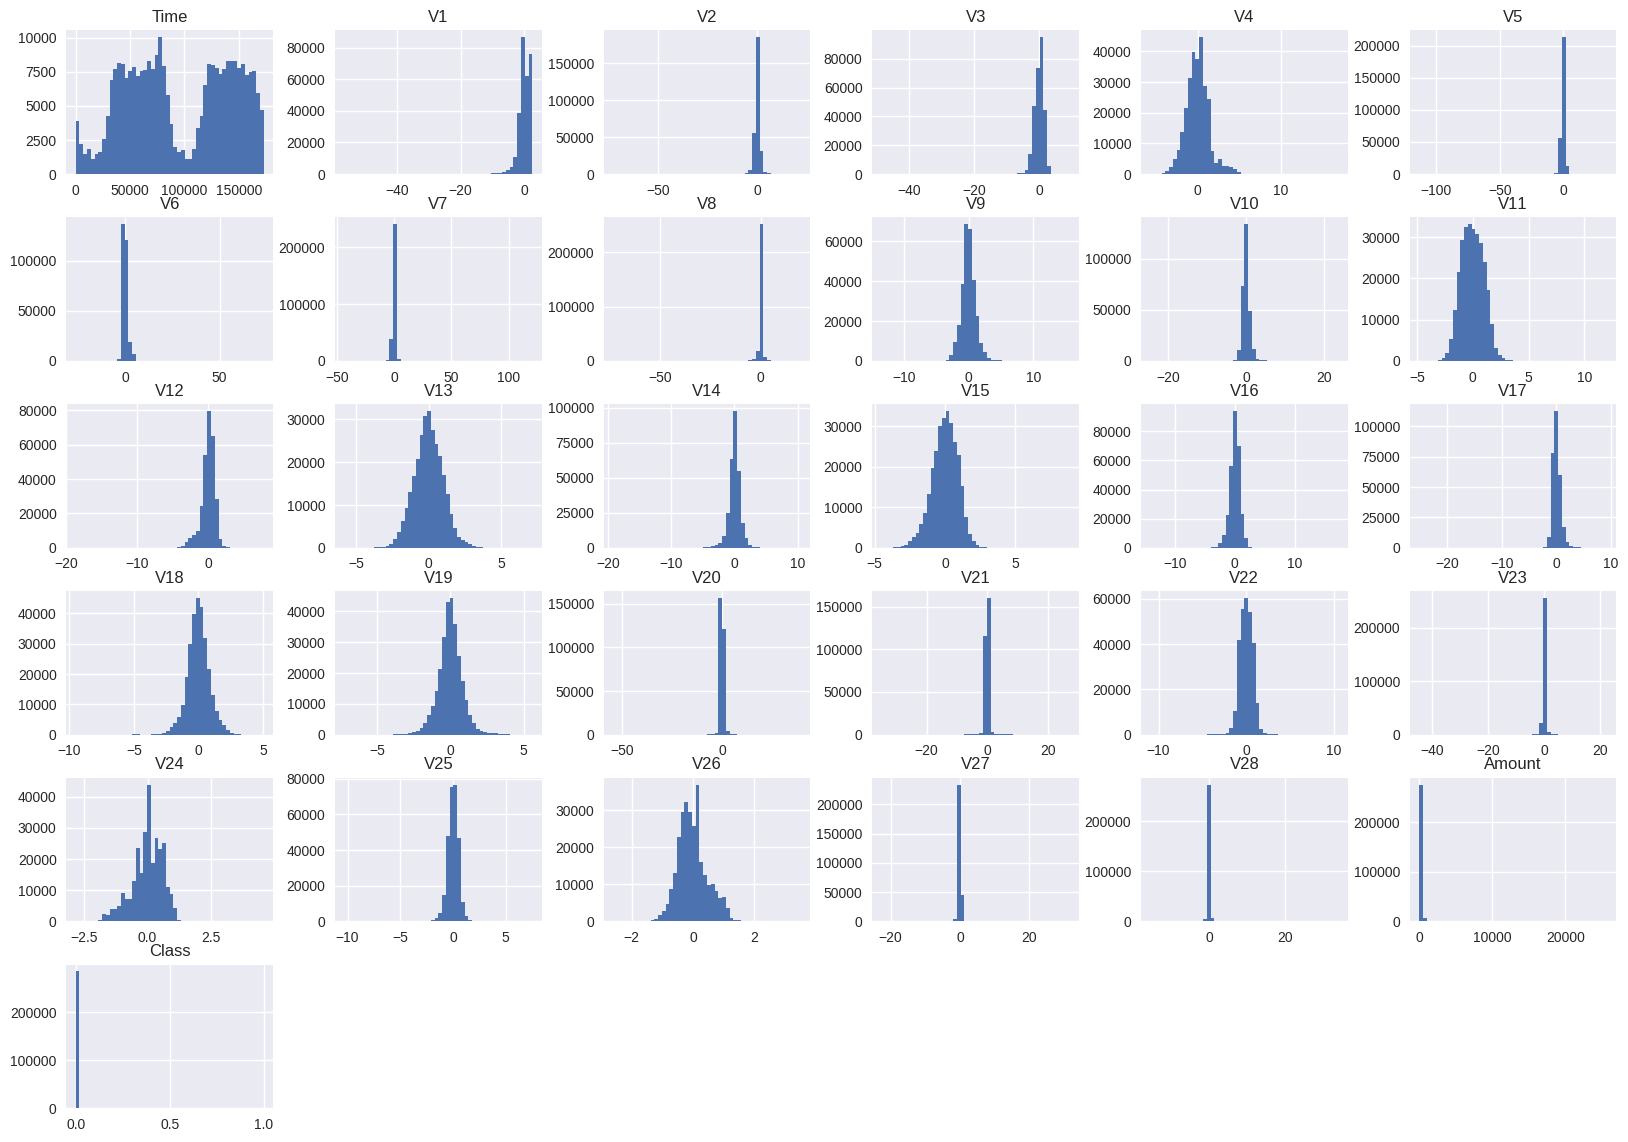

In [4]:
visualise(df)

In [5]:
x_train, x_test, y_train,y_test = trainsplit(df)


# SMOTE

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best params {'model__class_weight': {0: 1, 1: 100}, 'model__C': 0.1}
the best score AUC0.7075123682375485


/tmp/ipykernel_24/2346474243.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


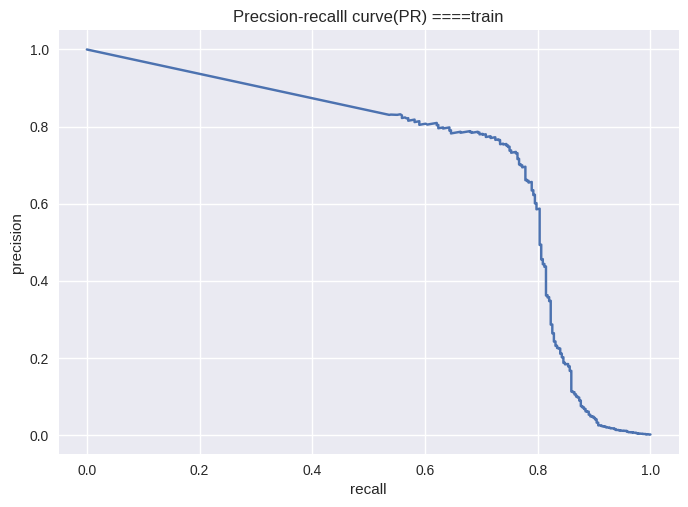

0.8917641000433038
[[76066  9241]
 [    7   129]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     85307
           1       0.01      0.95      0.03       136

    accuracy                           0.89     85443
   macro avg       0.51      0.92      0.48     85443
weighted avg       1.00      0.89      0.94     85443



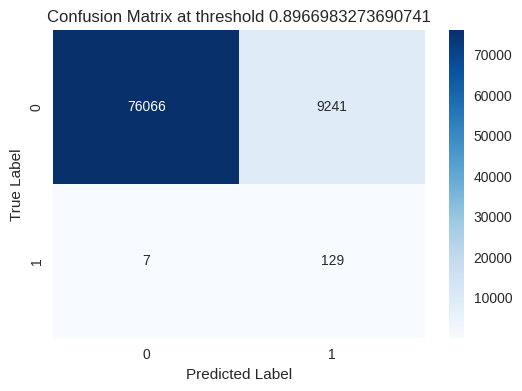

custom threhsold 0.2
0.09970389616469459
[[ 8383 76924]
 [    0   136]]
              precision    recall  f1-score   support

           0       1.00      0.10      0.18     85307
           1       0.00      1.00      0.00       136

    accuracy                           0.10     85443
   macro avg       0.50      0.55      0.09     85443
weighted avg       1.00      0.10      0.18     85443



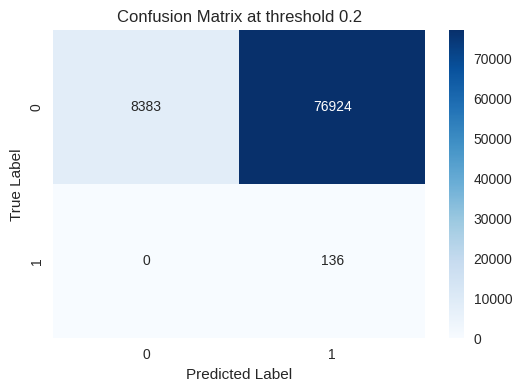

the PR_score0.754227218483836


In [6]:
l1 = grid_with_SMOTE(x_train,y_train)
threshPR1 = AUC_PR(l1,x_train,y_train)
y_pred1 = evaluate(x_test,y_test,l1,threshPR1)
print("custom threhsold 0.2")
y_pred11 = evaluate(x_test,y_test,l1,0.2)
y_scores1 = l1.predict_proba(x_test).values[:, 1]
precision1, recall1, thresholds = precision_recall_curve(y_test, y_scores1)
auc_score = auc(recall1, precision1)
print('the PR_score'+str(auc_score))


# with undersampling

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[2026-04-08 04:25:01.822] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
best params {'class_weight': {0: 1, 1: 100}, 'C': 1}
the best score AUC0.9668529270003366


/tmp/ipykernel_24/2346474243.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


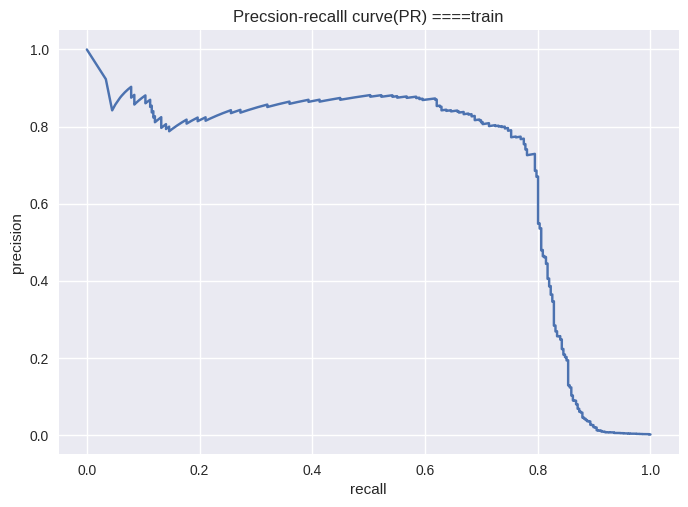

0.005407113514272673
[[  326 84981]
 [    0   136]]
              precision    recall  f1-score   support

           0       1.00      0.00      0.01     85307
           1       0.00      1.00      0.00       136

    accuracy                           0.01     85443
   macro avg       0.50      0.50      0.01     85443
weighted avg       1.00      0.01      0.01     85443



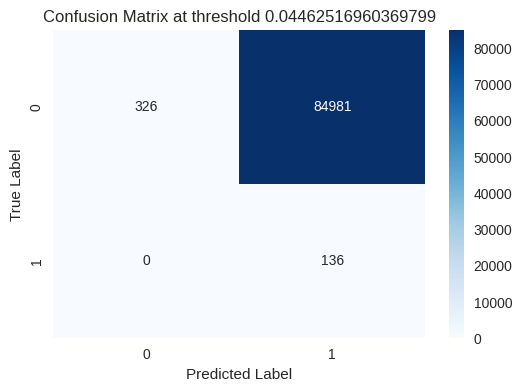

with custom threshold 0.2
0.011750523740973514
[[  868 84439]
 [    0   136]]
              precision    recall  f1-score   support

           0       1.00      0.01      0.02     85307
           1       0.00      1.00      0.00       136

    accuracy                           0.01     85443
   macro avg       0.50      0.51      0.01     85443
weighted avg       1.00      0.01      0.02     85443



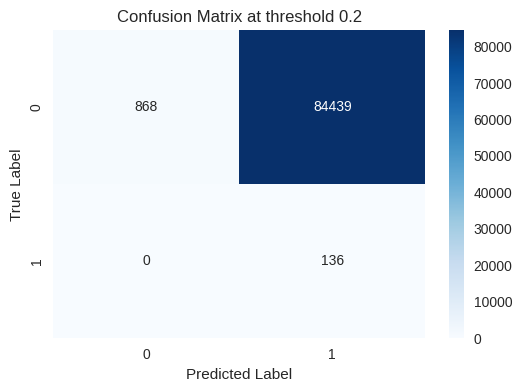

the PR_score0.6746111782843397


In [7]:
l2 = grid_with_downsampling(x_train,y_train)
threshPR2 = AUC_PR(l2,x_train,y_train)
y_pred2 = evaluate(x_test,y_test,l2,threshPR2)
print("with custom threshold 0.2")
y_pred22 = evaluate(x_test,y_test,l2,0.2)
y_scores = l2.predict_proba(x_test).values[:, 1]
precision2, recall2, thresholds = precision_recall_curve(y_test, y_scores)
auc_score = auc(recall2, precision2)
print('the PR_score'+str(auc_score))

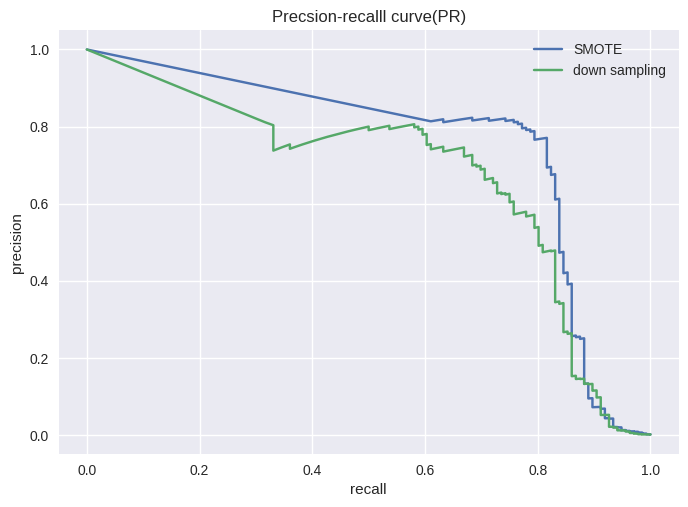

In [8]:

    plt.plot(recall1,precision1,label = "SMOTE")
    plt.plot(recall2,precision2,label = "down sampling")
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.title("Precsion-recalll curve(PR)")
    plt.legend()
    plt.show()